# Prueba de integración del proyecto Sudoku

Este notebook valida el proceso completo utilizando los módulos finales de la carpeta `app`.

```text
imagen
→ YOLO detecta el tablero
→ OpenCV corrige la perspectiva
→ se generan 81 celdas
→ la CNN reconoce vacío o número 1–9
→ se valida el puzzle
→ CNN + MRV + backtracking lo resuelven
→ se comprueba la solución
```

El notebook debe ejecutarse desde la carpeta `app`.

## 1. Importar librerías y funciones

In [1]:
import cv2
import matplotlib.pyplot as plt

from tensorflow import keras
from ultralytics import YOLO

from procesar_sudoku import procesar_sudoku
from clasificar_celdas import clasificar_celdas
from resolver_sudoku import (
    puzzle_parcial_valido,
    resolver_sudoku as resolver_con_backtracking,
    sudoku_valido
)

## 2. Definir las rutas

In [2]:
ruta_yolo = "models/best.pt"

ruta_class = (
    "models/best_class_0_9.keras"
)

ruta_juego = (
    "models/best_juego.keras"
)

ruta_imagen = (
    "../modelo_yolo/img_proc/images/test/"
    "sudoku_168_jpg.rf.pfhTWZY1G9sbBr6PPDKz.jpg"
)

## 3. Cargar los modelos

In [3]:
modelo_yolo = YOLO(
    ruta_yolo
)

modelo_class = keras.models.load_model(
    ruta_class
)

modelo_juego = keras.models.load_model(
    ruta_juego
)

print("Modelo YOLO cargado")

print(
    "Modelo class:",
    modelo_class.input_shape,
    "→",
    modelo_class.output_shape
)

print(
    "Modelo juego:",
    modelo_juego.input_shape,
    "→",
    modelo_juego.output_shape
)

Modelo YOLO cargado
Modelo class: (None, 28, 28, 1) → (None, 10)
Modelo juego: (None, 9, 9, 19) → (None, 9, 9, 9)


## 4. Cargar la imagen

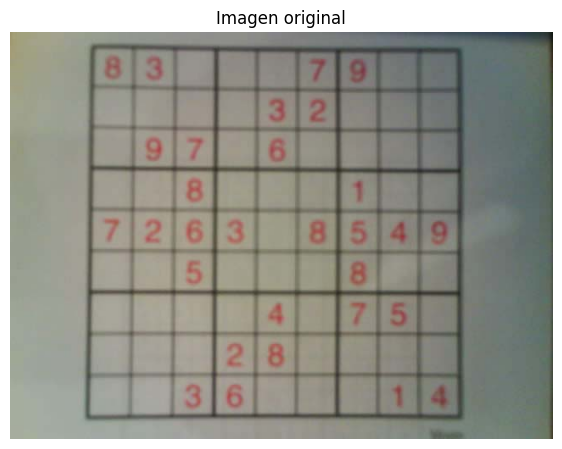

In [5]:
imagen = cv2.imread(
    ruta_imagen
)

if imagen is None:

    raise ValueError(
        "No se ha podido cargar la imagen."
    )

plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    cv2.cvtColor(
        imagen,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Imagen original"
)

plt.axis("off")
plt.show()

## 5. Detectar y procesar el tablero

`procesar_sudoku.py` utiliza YOLO para detectar el tablero y OpenCV para corregir su perspectiva y dividirlo en 81 celdas.

Celdas generadas: 81


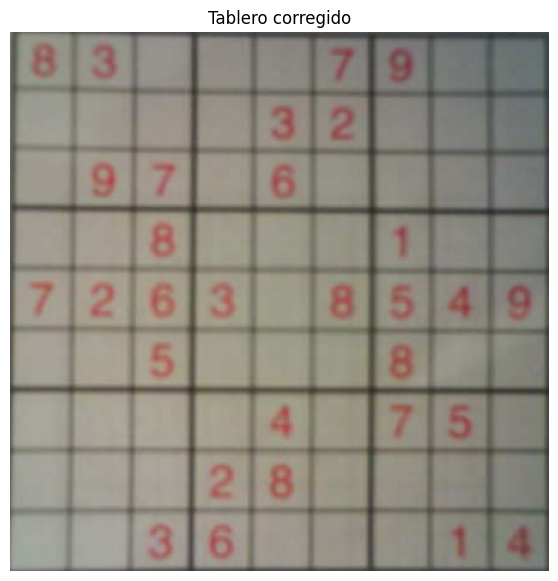

In [6]:
tablero, celdas = procesar_sudoku(
    imagen,
    modelo_yolo
)

print(
    "Celdas generadas:",
    len(celdas)
)

plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    cv2.cvtColor(
        tablero,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Tablero corregido"
)

plt.axis("off")
plt.show()

## 6. Clasificar las 81 celdas

`clasificar_celdas.py` prepara las celdas y utiliza `best_class_0_9.keras`.

```text
0 = celda vacía
1–9 = número reconocido
```

In [7]:
(
    puzzle,
    confianzas,
    contenido_detectado,
    celdas_preparadas
) = clasificar_celdas(
    celdas,
    modelo_class
)

print("Puzzle reconocido:")
print(puzzle)

print(
    "\nCeldas con número:",
    int(
        contenido_detectado.sum()
    )
)

print(
    "Celdas vacías:",
    int(
        81
        - contenido_detectado.sum()
    )
)

print(
    "Confianza media:",
    f"{confianzas.mean():.2%}"
)

Puzzle reconocido:
[[8 3 0 0 0 7 9 0 0]
 [0 0 0 0 3 2 0 0 0]
 [0 9 7 0 6 0 0 0 0]
 [0 0 8 0 0 0 1 0 0]
 [7 2 6 3 0 8 5 4 9]
 [0 0 5 0 0 0 8 0 0]
 [0 0 0 0 4 0 7 5 0]
 [0 0 0 2 8 0 0 0 0]
 [0 0 3 6 0 0 0 1 4]]

Celdas con número: 30
Celdas vacías: 51
Confianza media: 100.00%


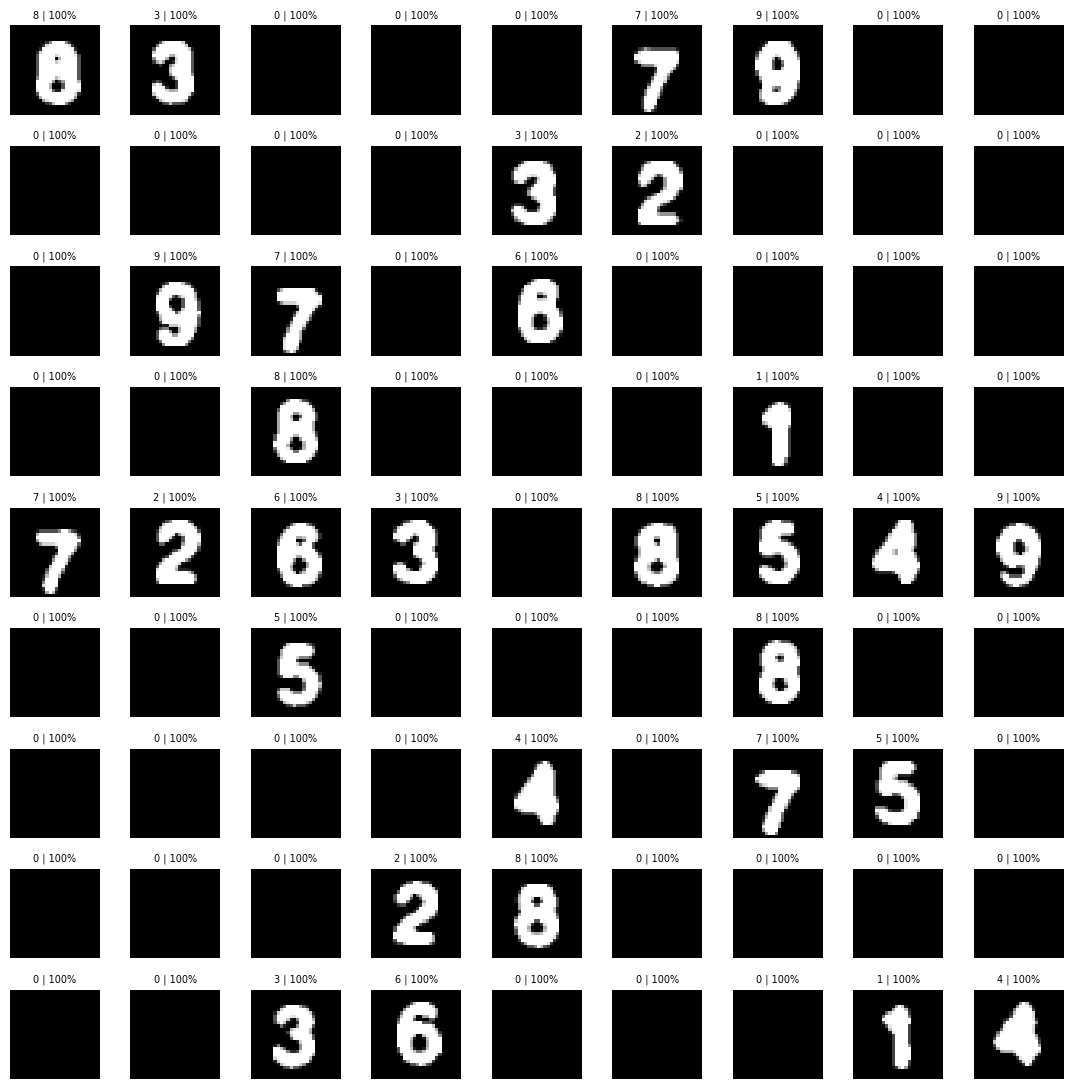

In [8]:
fig, axes = plt.subplots(
    9,
    9,
    figsize=(11, 11)
)

for indice, celda in enumerate(
    celdas_preparadas
):

    fila = indice // 9
    columna = indice % 9

    numero = puzzle[
        fila,
        columna
    ]

    confianza = confianzas[
        fila,
        columna
    ]

    axes[
        fila,
        columna
    ].imshow(
        celda,
        cmap="gray"
    )

    axes[
        fila,
        columna
    ].set_title(
        f"{numero} | {confianza:.0%}",
        fontsize=7
    )

    axes[
        fila,
        columna
    ].axis("off")

plt.tight_layout()
plt.show()

## 7. Validar el puzzle reconocido

In [9]:
if not puzzle_parcial_valido(
    puzzle
):

    raise ValueError(
        "El puzzle reconocido contiene contradicciones."
    )

print(
    "Puzzle inicial válido"
)

Puzzle inicial válido


## 9. Resolver el Sudoku

Aquí se ejecuta el **backtracking**.

La función `resolver_sudoku()` de `resolver_sudoku.py`:

1. utiliza MRV para elegir la celda con menos candidatos;
2. utiliza la CNN para ordenar los candidatos;
3. prueba el candidato más probable;
4. si aparece una contradicción, borra el número;
5. retrocede y prueba el siguiente candidato.

In [10]:
solucion, estadisticas = (
    resolver_con_backtracking(
        puzzle,
        modelo_juego,
        max_nodos=100000
    )
)

if solucion is None:

    raise ValueError(
        "No se ha encontrado una solución."
    )

print("Sudoku resuelto:")
print(solucion)

print(
    "\nNodos:",
    estadisticas["nodos"]
)

print(
    "Retrocesos:",
    estadisticas["retrocesos"]
)

Sudoku resuelto:
[[8 3 2 4 5 7 9 6 1]
 [6 5 1 9 3 2 4 8 7]
 [4 9 7 8 6 1 3 2 5]
 [3 4 8 5 9 6 1 7 2]
 [7 2 6 3 1 8 5 4 9]
 [9 1 5 7 2 4 8 3 6]
 [2 6 9 1 4 3 7 5 8]
 [1 7 4 2 8 5 6 9 3]
 [5 8 3 6 7 9 2 1 4]]

Nodos: 52
Retrocesos: 0


## 10. Validar y mostrar la solución

Sudoku válido: True


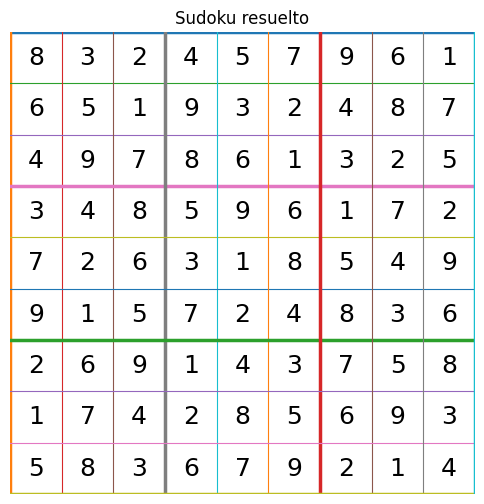

In [11]:
valido = sudoku_valido(
    solucion
)

print(
    "Sudoku válido:",
    valido
)

if not valido:

    raise ValueError(
        "La solución obtenida no es válida."
    )

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.invert_yaxis()

for i in range(10):

    grosor = (
        2.5
        if i % 3 == 0
        else 0.8
    )

    ax.plot(
        [0, 9],
        [i, i],
        linewidth=grosor
    )

    ax.plot(
        [i, i],
        [0, 9],
        linewidth=grosor
    )

for fila in range(9):
    for columna in range(9):

        ax.text(
            columna + 0.5,
            fila + 0.5,
            str(
                solucion[
                    fila,
                    columna
                ]
            ),
            ha="center",
            va="center",
            fontsize=18
        )

ax.set_title(
    "Sudoku resuelto"
)

ax.axis("off")
plt.show()

# Resultado de la prueba

La integración queda validada cuando:

- los tres modelos cargan correctamente;
- YOLO detecta el tablero;
- OpenCV genera 81 celdas;
- el clasificador genera un puzzle válido;
- el backtracking encuentra una solución;
- la solución cumple todas las reglas del Sudoku.